O fator de correção para os 100 primeiros está entre 1,2 e 1,35 (ranking 75 e 100).
Por regressão linear nestes dois pontos, o Top100 seria o 80 do ranking (80,55), logo, fator 1,25.

Metodologia: fazer a media e desvio padrão dos 80 primeiros do ranking.
Descobrir o desvio em relação a nota do Ranking Top80, e verificar o fator a partir do desvio.

Referência: 
PR_Top100: -1,28
PR_Top200: -2,29
PR_Top300: -3,30

(desvio do top 80 do ranking)
PR: -5,67 Desvios
PI: -6,50 Desvios
PE:

In [1]:
pr_80_stat = {'mean':0.808897,'std':0.019948,}
ref_desvios = [-1.28,-2.29,-3.30]
minha_nota = 98.8
total = 138

print('Top 100, 200, 300')
print('Percental: {:.2f}% {:.2f}% {:.2f}%'.format(*[(pr_80_stat['mean'] + pr_80_stat['std'] * nota)*100 for nota in ref_desvios]))
print('Nota: {:.1f} {:.1f} {:.1f}'.format(*[(pr_80_stat['mean'] + pr_80_stat['std'] * nota)*total for nota in ref_desvios]))
print('Diferenã: {:.1f} {:.1f} {:.1f}'.format(*[((pr_80_stat['mean'] + pr_80_stat['std'] * nota)*total-minha_nota) for nota in ref_desvios]))

Top 100, 200, 300
Percental: 78.34% 76.32% 74.31%
Nota: 108.1 105.3 102.5
Diferenã: 9.3 6.5 3.7


In [2]:
pi_80_stat = {'mean':0.849126,'std':0.026799,}
ref_desvios = [-1.28,-2.29,-3.30]
minha_nota = 162
total = 240

print('Top 100, 200, 300')
print('Percental: {:.2f}% {:.2f}% {:.2f}%'.format(*[(pi_80_stat['mean'] + pi_80_stat['std'] * nota)*100 for nota in ref_desvios]))
print('Nota: {:.1f} {:.1f} {:.1f}'.format(*[(pi_80_stat['mean'] + pi_80_stat['std'] * nota)*total for nota in ref_desvios]))
print('Diferenã: {:.1f} {:.1f} {:.1f}'.format(*[((pi_80_stat['mean'] + pi_80_stat['std'] * nota)*total-minha_nota) for nota in ref_desvios]))

# PI
# Ranking 40 (x1,23=50): 84,2%
# Ranking 33 (x1,23=41): 85%

# PE
# Ranking 40 (x1,23=50): 77,1%
# Ranking 5 (x1,23=6): 85%

Top 100, 200, 300
Percental: 81.48% 78.78% 76.07%
Nota: 195.6 189.1 182.6
Diferenã: 33.6 27.1 20.6


In [3]:
import pandas as pd
import os
from scipy.stats import norm

In [4]:
def get_df_sefaz(sefaz_escolhida):
    caminho = './' + sefaz_escolhida
    lista_arquivos = []
    for raiz, pastas, arquivos in os.walk(caminho):
        for nome_arquivo in arquivos:
            if 'pontos' in nome_arquivo:
                lista_arquivos.append(os.path.join(raiz, nome_arquivo))

    lista_arquivos.sort() 

    return pd.read_parquet(lista_arquivos[-1])


def converte_string(df_origem,colunas_p1,colunas_p2,colunas_demais):
    df = df_origem.copy()
    
    # Converte Colunas
    for col in colunas_p1 + colunas_p2 + colunas_demais:
        df[col] = df[col].str.replace(',', '.', regex=False).astype(float)
    
    return df

def get_aprovados(df_origem,colunas_p1,colunas_p2,colunas_demais,total_p1,total_p2,corte_p1,corte_p2,corte_obj,minimo_materia):
    df = df_origem.copy()
    
    df['p1'] = df[colunas_p1].sum(axis=1)
    df['p2'] = df[colunas_p2].sum(axis=1)
    df['obj'] = df['p1'] + df['p2']
    df['obj_prc'] = df['obj']/(total_p1 + total_p2)
    
    df['minima'] = df[colunas_p1 + colunas_p2].min(axis=1)
    
    # df_pontos_pr['aprovado']
    
    df['aprovado'] = (df['p1'] >= corte_p1*total_p1 ) & (df['p2'] >= corte_p2*total_p2 ) & (df['obj'] > corte_obj*(total_p1+total_p2) ) 
    if minimo_materia:
        df['aprovado'] = df['aprovado'] & (df['minima'] > 0 ) 

    return df

# SEFAZ MT

## Oficial

In [5]:
sefazmt_oficial = pd.read_excel('../../Anteriores/2023 SEFAZ-MT FGV/Resolução da Prova - SEFAZ-MT 2025-04-25.xlsx',sheet_name='OBJ_Preliminar')

In [6]:
sefazmt_oficial = get_aprovados(sefazmt_oficial,                             
    colunas_p1 = ['Língua Portuguesa',
       'Raciocínio Lógico', 'História e Geografia de MT',],
    colunas_p2 = [
       'Matemática Financeira e Estatística', 'Economia', 'Ética e Filosofia',
       'Direito Administrativo e Ética no Serviço Público',
       'Direito Constitucional', 'Direito Tributário',
       'Legislação Tributária Estadual',
       'Direito Civil, Direito Empresarial e noções de Direito Penal',
        'Contabilidade Geral e Contabilidade de Custos', 'Auditoria','Tecnologia da Informação',],
    colunas_demais = ['Total',],
    total_p1 = 30, total_p2 = 180,
    corte_p1 = 0.5,corte_p2 = 0.6,corte_obj=0,minimo_materia=False #  Direito Tributário, Legislação Tributária Estadual, Contabilidade Geral e Contabilidade de Custos, Auditoria e Tecnologia da Informação. 
)

In [7]:
sefazmt_oficial = sefazmt_oficial[['Inscrição', 'Nome', 'p1', 'p2', 'obj','obj_prc', 'minima', 'aprovado']]

In [8]:
sefazmt_stat = sefazmt_oficial['obj_prc'].describe()
sefazmt_stat

count    272.000000
mean       0.639391
std        0.037553
min        0.585714
25%        0.614286
50%        0.633333
75%        0.661905
max        0.771429
Name: obj_prc, dtype: float64

In [9]:
corte_mt_100  = sefazmt_oficial[sefazmt_oficial['aprovado']].sort_values(by='obj_prc',ascending=False).iloc[100]['obj_prc']
sefazmt_100 = sefazmt_oficial[(sefazmt_oficial['aprovado']) & (sefazmt_oficial['obj_prc'] >= corte_mt_100)]

In [10]:
sefazmt_oficial

,Inscrição,Nome,p1,p2,obj,obj_prc,minima,aprovado
0,486012063,Paulo De Oliveira Motta Filho,22,140,162,0.771429,2,True
1,486011339,José Francisco Dantas Mangueira Da Silva,21,136,157,0.747619,2,True
2,486012094,Miguel Lázaro Pimentel Vicentini,21,136,157,0.747619,0,True
3,486008170,Helio Fernandes Pacheco,23,132,155,0.738095,4,True
4,486015360,Benedito Daniel Nunes Da Silva,18,136,154,0.733333,0,True
...,...,...,...,...,...,...,...,...
267,486008504,Willian Alexandre De Paula,15,108,123,0.585714,2,True
268,486012731,Pedro Ivo Silvany De Araujo Leite Passos,15,108,123,0.585714,0,True
269,486012446,Renan Bambini Moreira,15,108,123,0.585714,0,True
270,486018571,Alexander Lopes De Freitas Teixeira,15,108,123,0.585714,0,True


In [11]:
sefazmt_100_stat = sefazmt_100['obj_prc'].describe()
sefazmt_100_stat

count    112.000000
mean       0.675765
std        0.028761
min        0.642857
25%        0.652381
50%        0.666667
75%        0.695238
max        0.771429
Name: obj_prc, dtype: float64

<Axes: >

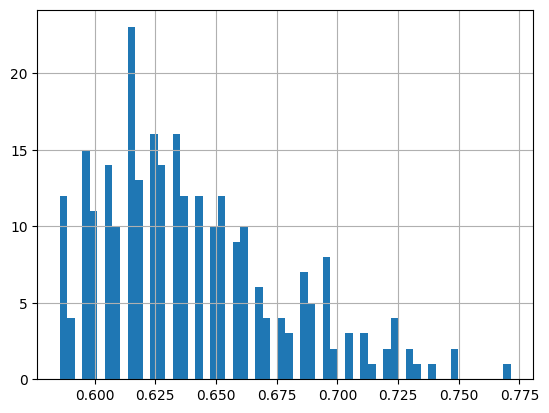

In [12]:
sefazmt_oficial['obj_prc'].hist(bins=60)

In [13]:
2359/1109

2.127141568981064

In [14]:
# Média e desvio padrão da distribuição normal
media = sefazpr_100_stat['mean']
desvio = sefazpr_100_stat['std']

# Valor acima do qual queremos a frequência acumulada
x = 98.8/142

# P(X > 60)
prob = 1 - norm.cdf(x, loc=media, scale=desvio)
print('Media {:.2f}/{:.2f} Desvio {:.2f}/{:.2f} Estatistica Acumulada: {:.2f}'.format(x*100,media*100,(x-media)/desvio,desvio*100,prob*100))
prob*2359


NameError: name 'sefazpr_100_stat' is not defined

# SEFAZ PR

## Oficial

In [ ]:
sefazpr_oficial = pd.read_excel('../../2025-02-10 SEFAZ-PR/sefaz-pr_obj-definitivo.xlsx')

In [ ]:
sefazpr_oficial.columns

In [ ]:
sefazpr_oficial = get_aprovados(sefazpr_oficial,                             
    colunas_p1 = ['por', 'rlm', 'ap', 'ad', 'da','dce', 'dc', 'lt', 'dt',],
    colunas_p2 = ['efp', 'cga', 'pad'],
    colunas_demais = ['obj',],
    total_p1 = 84, total_p2 = 58,
    corte_p1 = 0.5,corte_p2 = 0.5,corte_obj=0.5,minimo_materia=True
)

In [ ]:
sefazpr_oficial = sefazpr_oficial[['inscricao', 'nome', 'p1', 'p2', 'obj','obj_prc', 'minima', 'aprovado']]

In [ ]:
sefazpr_stat = sefazpr_oficial['obj_prc'].describe()
sefazpr_stat

In [ ]:
sefazpr_oficial['obj_prc'].hist(bins=60)

## SEFAZ PR Ranking

In [ ]:
sefazpr = get_df_sefaz('sefaz-pr')
sefazpr = converte_string(sefazpr,                             
    colunas_p1 = ['por', 'rlm', 'ap', 'ad', 'da', 'dce','dc', 'lt', 'dt'],
    colunas_p2 = ['efp', 'cga', 'pad',],
    colunas_demais = ['total', 'dis', 'tít',],
)
sefazpr = get_aprovados(sefazpr,                             
    colunas_p1 = ['por', 'rlm', 'ap', 'ad', 'da', 'dce','dc', 'lt', 'dt'],
    colunas_p2 = ['efp', 'cga', 'pad',],
    colunas_demais = ['total', 'dis', 'tít',],
    total_p1 = 84, total_p2 = 58,
    corte_p1 = 0.5,corte_p2 = 0.5,corte_obj=0.5,minimo_materia=True
)
sefazpr = sefazpr[['posicao', 'usuario', 'p1', 'p2', 'obj','obj_prc', 'minima', 'aprovado']]
sefazpr['posicao'] = sefazpr['posicao'].apply(lambda x: int(x.replace('º','').replace('.','')))

In [ ]:
# df_pontos_pr['total'] = df_pontos_pr['total'].apply(lambda x: float(x.replace(',','.')))
sefazpr_alvo = sefazpr[sefazpr['aprovado']]
print(sefazpr_alvo.shape)

sefazpr_alvo_stat = sefazpr_alvo['obj_prc'].describe()
sefazpr_alvo_stat

In [ ]:
corte_pr_100  = sefazpr[sefazpr['aprovado']].sort_values(by='obj_prc',ascending=False).iloc[100]['obj_prc']
sefazpr_100 = sefazpr[(sefazpr['aprovado']) & (sefazpr['obj_prc'] >= corte_pr_100)]

In [ ]:
sefazpr_100_stat = sefazpr_100['obj_prc'].describe()
sefazpr_100_stat

In [ ]:
sefazpr_alvo[['obj_prc']].hist(bins=40)

In [ ]:
# (0.699 - sefazpr_alvo_stat.loc['mean']['total_prc'])/sefazpr_alvo_stat.loc['std']['total_prc']

## Comparação de Rankings

In [ ]:
corte_pr_80  = sefazpr[sefazpr['aprovado']].sort_values(by='obj_prc',ascending=False).iloc[80]['obj_prc']
sefazpr_80 = sefazpr[(sefazpr['aprovado']) & (sefazpr['obj_prc'] >= corte_pr_80)]

In [ ]:
sefazpr_alvo_stat = sefazpr_80['obj_prc'].describe()
sefazpr_alvo_stat

In [ ]:
lista_sefazpr_oficial_posicao = []

for posicao in [25,50,75,100,150,200,300,400,500,600,700,800]:
    dict_registro = {
        'ranking': posicao,
        'ranking_nota': sefazpr_alvo.sort_values(by='obj_prc',ascending=False).iloc[posicao]['obj_prc']
    }
    dict_registro['ranking_nota_norm'] = (dict_registro['ranking_nota'] - sefazpr_100_stat['mean'])/sefazpr_100_stat['std']
    dict_registro['ranking_nota_prob'] = 1 - norm.cdf(dict_registro['ranking_nota'] , loc=sefazpr_100_stat['mean'], scale=sefazpr_100_stat['std']) 
    dict_registro['oficial'] = sefazpr_oficial[sefazpr_oficial['obj_prc'] >= dict_registro['ranking_nota']].shape[0]

    lista_sefazpr_oficial_posicao.append(dict_registro)

In [ ]:
sefazpr_oficial_posicao = pd.DataFrame(lista_sefazpr_oficial_posicao)
sefazpr_oficial_posicao['sobre_ranking'] = sefazpr_oficial_posicao['oficial']/sefazpr_oficial_posicao['ranking']
sefazpr_oficial_posicao

# Nova comparação

In [ ]:
corte_pr_oficial_100  = sefazpr_oficial[sefazpr_oficial['aprovado']].sort_values(by='obj_prc',ascending=False).iloc[100]['obj_prc']
sefazpr_oficial_100 = sefazpr_oficial[(sefazpr_oficial['aprovado']) & (sefazpr_oficial['obj_prc'] >= corte_pr_oficial_100)]
sefazpr_oficial_stat = sefazpr_oficial_100['obj_prc'].describe()
sefazpr_oficial_stat

In [ ]:
lista_sefazpr_oficial_posicao = []

for posicao in [25,50,75,100,150,200,300,400,500,600,700,800,900,1000,1200]:
    dict_registro = {
        'oficial': posicao,
        'oficial_nota': sefazpr_oficial.sort_values(by='obj_prc',ascending=False).iloc[posicao]['obj_prc']
    }
    dict_registro['oficial_nota_norm'] = (dict_registro['oficial_nota'] - sefazpr_oficial_stat['mean'])/sefazpr_oficial_stat['std']
    dict_registro['oficial_nota_prob'] = 1 - norm.cdf(dict_registro['oficial_nota'] , loc=sefazpr_oficial_stat['mean'], scale=sefazpr_oficial_stat['std']) 
    dict_registro['ranking'] = sefazpr[sefazpr['obj_prc'] >= dict_registro['oficial_nota']].shape[0]

    lista_sefazpr_oficial_posicao.append(dict_registro)

In [ ]:
sefazpr_oficial_posicao = pd.DataFrame(lista_sefazpr_oficial_posicao)
# sefazpr_oficial_posicao['sobre_ranking'] = sefazpr_oficial_posicao['oficial']/sefazpr_oficial_posicao['ranking']
sefazpr_oficial_posicao['sobre_ranking'] = sefazpr_oficial_posicao['oficial']/sefazpr_oficial_posicao['ranking']
sefazpr_oficial_posicao

In [ ]:
sefazpr[sefazpr['usuario'].str.contains('cf_auditor')]

# SEFAZ PE
## Oficial

In [15]:
sefazpe_oficial = pd.read_excel('../../Anteriores/2022 SEFAZ-PE FCC/Comparação de Ranking.xlsx',sheet_name='Ampla')
sefazpe_oficial['p1'] = sefazpe_oficial['Conhec. Gerais (P1)'].apply(lambda x: x.split()[2])
sefazpe_oficial['p2'] = sefazpe_oficial['Conhec. Específicos (P2)'].apply(lambda x: x.split()[2])

sefazpe_oficial['p1'] = sefazpe_oficial['p1'].astype('float')
sefazpe_oficial['p2'] = sefazpe_oficial['p2'].astype('float')
sefazpe_oficial['obj'] = sefazpe_oficial['p1'] + sefazpe_oficial['p2']
sefazpe_oficial['obj_prc'] = sefazpe_oficial['obj']/240

sefazpe_oficial[['NOME','CLASS','p1','p2','obj','obj_prc']]

,NOME,CLASS,p1,p2,obj,obj_prc
0,ABRAM FAEIRSTEIN PACHECO,1,69.0,142.0,211.0,0.879167
1,LUISA FERRAZ TORRES DE LUNA,2,68.0,142.0,210.0,0.875000
2,LUCAS MARINHO MACIEL DE AZEVEDO,3,70.0,140.0,210.0,0.875000
3,KELSON CUNHA CHAVES,4,60.0,146.0,206.0,0.858333
4,THIAGO LIMA DE FREITAS NOBRE,5,62.0,144.0,206.0,0.858333
...,...,...,...,...,...,...
509,VANESSA REGINA GONCALVES DE SOUZA NASCIMENTO,510,52.0,92.0,144.0,0.600000
510,ISAIAS MENDONCA CAMPOS,511,40.0,104.0,144.0,0.600000
511,GABRIEL DORIA PARES BRUNELLI,512,42.0,102.0,144.0,0.600000
512,PEDRO CAMPOS BEZERRA,513,40.0,104.0,144.0,0.600000


In [16]:
sefazpe_stat = sefazpe_oficial['obj_prc'].describe()
sefazpe_stat

count    514.000000
mean       0.682012
std        0.057961
min        0.600000
25%        0.633333
50%        0.675000
75%        0.720833
max        0.879167
Name: obj_prc, dtype: float64

<Axes: >

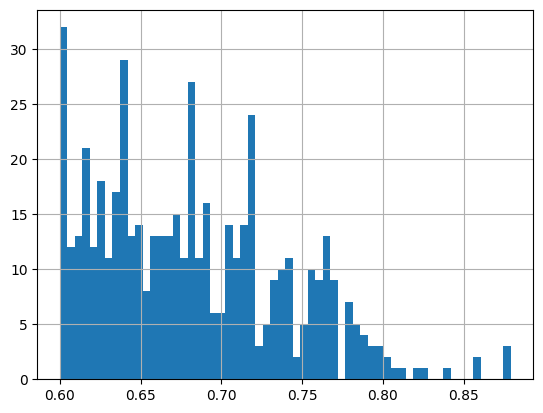

In [17]:
sefazpe_oficial['obj_prc'].hist(bins=60)

In [18]:
# # Média e desvio padrão da distribuição normal
# media = sefazpr_stat['mean']
# desvio = sefazpr_stat['std']

# # Valor acima do qual queremos a frequência acumulada
# x = 98.8/142

# # P(X > 60)
# prob = 1 - norm.cdf(x, loc=media, scale=desvio)
# print('Media {:.2f}/{:.2f} Desvio {:.2f}/{:.2f} Estatistica Acumulada: {:.2f}'.format(x*100,media*100,(x-media)/desvio,desvio*100,prob*100))
# prob*2359


## Ranking

In [19]:
sefazpe = get_df_sefaz('sefaz-pe')
sefazpe = converte_string(sefazpe,                                 
    colunas_p1 = ['lp', 'rle', 'dc', 'da', 'de', 'cgc','ti', ],
    colunas_p2 = [ 'efp', 'dt', 'le', 'af', 'cp', 'df',],
    colunas_demais = ['total', ],
)
sefazpe = get_aprovados(sefazpe,                                       
    colunas_p1 = ['lp', 'rle', 'dc', 'da', 'de', 'cgc','ti', ],
    colunas_p2 = [ 'efp', 'dt', 'le', 'af', 'cp', 'df',],
    colunas_demais = ['total', ],
    total_p1 = 80, total_p2 = 160,
    corte_p1 = 0.5,corte_p2 = 0.5,corte_obj=0.6,minimo_materia=False
)
sefazpe = sefazpe[['posicao', 'usuario', 'p1', 'p2', 'obj','obj_prc', 'minima', 'aprovado']]
sefazpe['posicao'] = sefazpe['posicao'].apply(lambda x: int(x.replace('º','').replace('.','')))

In [20]:
# df_pontos_pr['total'] = df_pontos_pr['total'].apply(lambda x: float(x.replace(',','.')))
# sefazpi['total_prc'] = sefazpi['total']/240
sefazpe_alvo = sefazpe[sefazpe['aprovado']]
print(sefazpe_alvo.shape)

sefazpe_alvo_stat = sefazpe_alvo['obj_prc'].describe()
sefazpe_alvo_stat

(242, 8)


count    242.000000
mean       0.712982
std        0.057671
min        0.604167
25%        0.675000
50%        0.712500
75%        0.754167
max        0.879167
Name: obj_prc, dtype: float64

In [21]:
corte_pe_100  = sefazpe[sefazpe['aprovado']].sort_values(by='obj_prc',ascending=False).iloc[100]['obj_prc']
sefazpe_100 = sefazpe[(sefazpe['aprovado']) & (sefazpe['obj_prc'] >= corte_pe_100)]

In [22]:
sefazpe_100_stat = sefazpe_100['obj_prc'].describe()
sefazpe_100_stat

count    109.000000
mean       0.764794
std        0.035244
min        0.720833
25%        0.741667
50%        0.758333
75%        0.783333
max        0.879167
Name: obj_prc, dtype: float64

In [23]:
# Média e desvio padrão da distribuição normal
media = sefazpe_alvo_stat['mean']
desvio = sefazpe_alvo_stat['std']

# Valor acima do qual queremos a frequência acumulada
# x = 162/240

# P(X > 60)
# prob = 1 - norm.cdf(x, loc=media, scale=desvio)

# print('Media {:.2f}/{:.2f} Desvio {:.2f}/{:.2f} Estatistica Acumulada: {:.2f}'.format(x*100,media*100,(x-media)/desvio,desvio*100,prob*100))
# prob*323*2


array([[<Axes: title={'center': 'obj_prc'}>]], dtype=object)

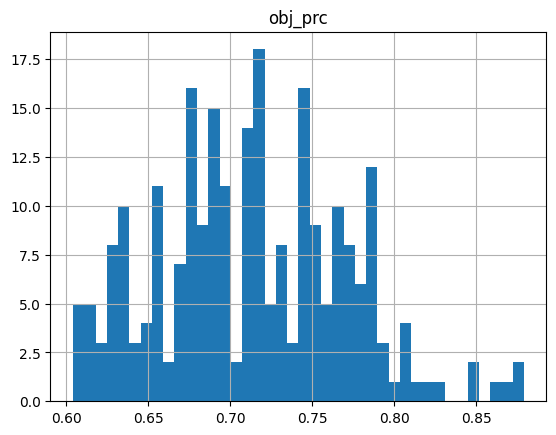

In [24]:
sefazpe_alvo[['obj_prc']].hist(bins=40)

In [25]:
lista_sefazpe_oficial_posicao = []

for posicao in [25,50,75,100,150,200]:
    dict_registro = {
        'ranking': posicao,
        'ranking_nota': sefazpe_alvo.sort_values(by='obj_prc',ascending=False).iloc[posicao]['obj_prc']
    }
    dict_registro['ranking_nota_norm'] = (dict_registro['ranking_nota'] - sefazpe_stat['mean'])/sefazpe_stat['std']
    dict_registro['ranking_nota_prob'] = 1 - norm.cdf(dict_registro['ranking_nota'] , loc=sefazpe_stat['mean'], scale=sefazpe_stat['std']) 
    
    # dict_registro['oficial'] = sefazpr_oficial[sefazpr_oficial['obj_prc'] >= dict_registro['ranking_nota']].shape[0]

    lista_sefazpe_oficial_posicao.append(dict_registro)

In [26]:
sefazpe_oficial_posicao = pd.DataFrame(lista_sefazpe_oficial_posicao)
# sefazpi_oficial_posicao['sobre_ranking'] = sefazpr_oficial_posicao['oficial']/sefazpr_oficial_posicao['ranking']
sefazpe_oficial_posicao

,ranking,ranking_nota,ranking_nota_norm,ranking_nota_prob
0,25,0.783333,1.748088,0.040224
1,50,0.762500,1.388652,0.082469
2,75,0.745833,1.101104,0.135426
3,100,0.720833,0.669781,0.251499
4,150,0.691667,0.166571,0.433854
5,200,0.654167,-0.480413,0.684533


## Comparação de Ranking

In [27]:
lista_sefazpe_oficial_posicao = []

for posicao in [25,50,75,100,150,200,]:
    dict_registro = {
        'ranking': posicao,
        'ranking_nota': sefazpe_alvo.sort_values(by='obj_prc',ascending=False).iloc[posicao]['obj_prc']
    }
    dict_registro['ranking_nota_norm'] = (dict_registro['ranking_nota'] - sefazpe_100_stat['mean'])/sefazpe_100_stat['std']
    dict_registro['ranking_nota_prob'] = 1 - norm.cdf(dict_registro['ranking_nota'] , loc=sefazpe_100_stat['mean'], scale=sefazpe_100_stat['std']) 
    dict_registro['oficial'] = sefazpe_oficial[sefazpe_oficial['obj_prc'] >= dict_registro['ranking_nota']].shape[0]

    lista_sefazpe_oficial_posicao.append(dict_registro)

In [28]:
sefazpe_oficial_posicao = pd.DataFrame(lista_sefazpe_oficial_posicao)
sefazpe_oficial_posicao['sobre_ranking'] = sefazpe_oficial_posicao['oficial']/sefazpe_oficial_posicao['ranking']
sefazpe_oficial_posicao

,ranking,ranking_nota,ranking_nota_norm,ranking_nota_prob,oficial,sobre_ranking
0,25,0.783333,0.526044,0.299429,27,1.080000
1,50,0.762500,-0.065078,0.525944,60,1.200000
2,75,0.745833,-0.537975,0.704703,82,1.093333
3,100,0.720833,-1.247322,0.893860,130,1.300000
4,150,0.691667,-2.074893,0.981002,211,1.406667
5,200,0.654167,-3.138913,0.999152,322,1.610000


# SEFAZ PI

In [ ]:
# media + 1 desvio = 84,123% x 
# ausencia média = 30%
# aprovados = 5.094 x 84,123% * 70% = 566
# chamados para discursiva = 85

In [ ]:
sefazpi = get_df_sefaz('sefaz-pi')
sefazpi = converte_string(sefazpi,                                 
    colunas_p1 = ['por', 'mf', 'erl', 'dc', 'da', 'dcd','cr','ti', ],
    colunas_p2 = [ 'dt', 'lte', 'cg', 'ca', 'cc','aud',],
    colunas_demais = ['total', 'tít',],
)
sefazpi = get_aprovados(sefazpi,                             
    colunas_p1 = ['por', 'mf', 'erl', 'dc', 'da', 'dcd','cr','ti',],
    colunas_p2 = [  'dt', 'lte', 'cg', 'ca', 'cc','aud',],
    colunas_demais = ['total', 'tít',],
    total_p1 = 80,total_p2 = 160,
    corte_p1 = 0,corte_p2 = 0,corte_obj=0,minimo_materia=False
)
sefazpi = sefazpi[['posicao', 'usuario', 'p1', 'p2', 'obj','obj_prc', 'minima', 'aprovado']]
sefazpi['posicao'] = sefazpi['posicao'].apply(lambda x: int(x.replace('º','').replace('.','')))

In [ ]:
# df_pontos_pr['total'] = df_pontos_pr['total'].apply(lambda x: float(x.replace(',','.')))
# sefazpi['total_prc'] = sefazpi['total']/240
sefazpi_alvo = sefazpi[sefazpi['aprovado']]
print(sefazpi_alvo.shape)

sefazpi_stat = sefazpi_alvo['obj_prc'].describe()
sefazpi_stat

In [ ]:
corte_pi_80  = sefazpi[sefazpi['aprovado']].sort_values(by='obj_prc',ascending=False).iloc[80]['obj_prc']
sefazpi_80 = sefazpi[(sefazpi['aprovado']) & (sefazpi['obj_prc'] >= corte_pi_80)].copy()

In [ ]:
sefazpi_80_stat = sefazpi_80['obj_prc'].describe()
sefazpi_80_stat

In [ ]:
# Média e desvio padrão da distribuição normal
media = sefazpi_80_stat['mean']
desvio = sefazpi_80_stat['std']

# Valor acima do qual queremos a frequência acumulada
x = 162/240

# P(X > 60)
prob = 1 - norm.cdf(x, loc=media, scale=desvio)

print('Media {:.2f}/{:.2f} Desvio {:.2f}/{:.2f} Estatistica Acumulada: {:.2f}'.format(x*100,media*100,(x-media)/desvio,desvio*100,prob*100))
prob*323*2


In [ ]:
sefazpi_alvo[['obj_prc']].hist(bins=40)

In [ ]:
lista_sefazpi_oficial_posicao = []

for posicao in [25,50,75,100,150,200,250,300]:
    dict_registro = {
        'ranking': posicao,
        'ranking_nota': sefazpi_alvo.sort_values(by='obj_prc',ascending=False).iloc[posicao]['obj_prc']
    }
    dict_registro['ranking_nota_norm'] = (dict_registro['ranking_nota'] - sefazpi_100_stat['mean'])/sefazpi_100_stat['std']
    dict_registro['ranking_nota_prob'] = 1 - norm.cdf(dict_registro['ranking_nota'] , loc=sefazpi_100_stat['mean'], scale=sefazpi_100_stat['std']) 
    
    # dict_registro['oficial'] = sefazpr_oficial[sefazpr_oficial['obj_prc'] >= dict_registro['ranking_nota']].shape[0]

    lista_sefazpi_oficial_posicao.append(dict_registro)

In [ ]:
sefazpi_oficial_posicao = pd.DataFrame(lista_sefazpi_oficial_posicao)
# sefazpi_oficial_posicao['sobre_ranking'] = sefazpr_oficial_posicao['oficial']/sefazpr_oficial_posicao['ranking']
sefazpi_oficial_posicao

# Intersecção de rankings

In [ ]:
sefazpi[sefazpi['usuario'] == 'cf_auditor']

In [ ]:
sefazpr[sefazpr['usuario'].isin(sefazpi['usuario'])]['obj_prc'].describe()

In [ ]:
sefazpi[sefazpi['usuario'].isin(sefazpr['usuario'])]['obj_prc'].hist(bins=30)

In [ ]:
sefazpi[sefazpi['usuario'].isin(sefazpe['usuario'])]['obj_prc'].describe()

In [ ]:
sefazpr[sefazpr['usuario'].isin(sefazpe['usuario'])]['obj_prc'].describe()

In [ ]:
ranking_junto = sefazpr[['usuario','posicao','obj_prc']].merge(
    sefazpi[['usuario','posicao','obj_prc']],on='usuario',suffixes=['','_pi'],how='outer'
).merge(
    sefazpe[['usuario','posicao','obj_prc']],on='usuario',suffixes=['_pr','_pe'],how='outer'
)
ranking_junto['notas'] = (~ranking_junto['obj_prc_pr'].isna()).astype(int) + (~ranking_junto['obj_prc_pi'].isna()).astype(int) + (~ranking_junto['obj_prc_pe'].isna()).astype(int)
ranking_junto['posicao_minima'] = ranking_junto[['posicao_pr','posicao_pi','posicao_pe',]].min(axis=1)
ranking_junto[ranking_junto['notas'] > 1].sort_values(by='posicao_pi',ascending=True)[['usuario', 'posicao_pr', 'posicao_pi','posicao_pe','obj_prc_pr',  'obj_prc_pi',
        'obj_prc_pe', 'notas', 'posicao_minima']].fillna('').tail(60)#.iloc[50:100]

In [ ]:
sefazpi[sefazpi['usuario'].isin(sefazpe['usuario'])]['obj_prc'].hist(bins=30)

In [ ]:
sefazpr_oficial